# TopoMetry — Multi-Batch Integration

When single-cell datasets are produced in different laboratories, sequencing platforms, or experimental batches, systematic technical differences ("batch effects") can obscure the underlying biology. Integration methods aim to remove these unwanted technical sources of variation while preserving genuine biological signal.

TopoMetry provides a **CCA-anchor integration** pipeline (inspired by [Seurat v3](https://doi.org/10.1016/j.cell.2019.05.031), Stuart *et al.* 2019) that corrects batch effects in log-normalised expression space and then builds geometry-aware spectral scaffolds and layouts on the corrected data. Two complementary workflows are supported:

1. **Full integration** — correct all batches simultaneously in a single run.
2. **Reference mapping** — build a stable reference atlas from a subset of batches, then sequentially map new (query) batches onto it.

In this tutorial you will learn both workflows end-to-end, from quality control to final visualisation and quantitative evaluation.

**Dataset:** `Immune_ALL_human.h5ad` from the [scIB benchmark](https://doi.org/10.1038/s41592-021-01336-8) (Luecken *et al.*, 2022) — human immune cells across 10 batches and 16 annotated cell types.

---
## Environment & imports

Besides `topometry` and standard Python libraries, we use [scanpy](https://scanpy.readthedocs.io/) and the `AnnData` format to manage our single-cell data.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scanpy as sc
import anndata as ad
import topo as tp

# figure settings
sc.settings.set_figure_params(dpi=120, facecolor='white', fontsize=14)
sc.settings.verbosity = 1

print(f'scanpy {sc.__version__}  |  topo {tp.__version__}')

scanpy 1.10.3  |  topo 1.0.2


---
## Load data

The Immune_ALL_human dataset contains ~33,500 cells from 10 batches spanning multiple tissues and sequencing platforms. The expression matrix is already log-normalised (`adata.X`), while raw counts are stored in `adata.layers['counts']`. This is a curated dataset, so we can skip quality-control for demonstration purposes.

You can download the dataset from [Figshare](https://figshare.com/ndownloader/files/27686835).

In [2]:
adata = ad.read_h5ad('Immune_ALL_human.h5ad')

# Create a convenient 'cell_type' alias for the annotation column
adata.obs['cell_type'] = adata.obs['final_annotation'].copy()

print(adata)
print(f"\nBatches   ({adata.obs['batch'].nunique()}): {sorted(adata.obs['batch'].unique())}")
print(f"Cell types ({adata.obs['cell_type'].nunique()}): {sorted(adata.obs['cell_type'].unique())}")
print(f"adata.X max = {adata.X.max():.3f}  (already log-normalised)")

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'cell_type'
    layers: 'counts'

Batches   (10): ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P', 'Oetjen_U', 'Sun_sample1_CS', 'Sun_sample2_KC', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']
Cell types (16): ['CD10+ B cells', 'CD14+ Monocytes', 'CD16+ Monocytes', 'CD20+ B cells', 'CD4+ T cells', 'CD8+ T cells', 'Erythrocytes', 'Erythroid progenitors', 'HSPCs', 'Megakaryocyte progenitors', 'Monocyte progenitors', 'Monocyte-derived dendritic cells', 'NK cells', 'NKT cells', 'Plasma cells', 'Plasmacytoid dendritic cells']
adata.X max = 12.041  (already log-normalised)


---
## Workflow 1 — Full integration of all batches

In this workflow we correct all batches simultaneously. This is the simplest approach and works well when you have all your data available upfront.

The pipeline consists of four steps:

```
prepare_for_integration  →  run_cca_integration  →  fit_adata  →  compute_all_integration_metrics
```

### Prepare data for integration

`tp.sc.prepare_for_integration` ensures the expression matrix is in the correct format and selects **highly variable genes (HVGs)** shared across batches — the features that will drive the integration.

Since our data is already log-normalised, we set `input_type='lognorm'` so no additional normalisation is applied. If you have raw count data, use `input_type='counts'` instead.

In [6]:
# Work on a copy so the original adata is preserved for Workflow 2
adata_w1 = adata.copy()

tp.sc.prepare_for_integration(
    adata_w1,
    batch_key='batch',
    input_type='lognorm',
    select_hvgs=True,
    n_hvgs=2000,
)

n_feats = len(adata_w1.uns['integration_features'])
print(f"Selected {n_feats} integration features across {adata_w1.obs['batch'].nunique()} batches.")

Selected 2000 integration features across 10 batches.


### Run CCA integration

`tp.sc.run_cca_integration` performs the actual batch correction:
- Builds a **guide tree** to determine the optimal pairwise merge order.
- For each merge: computes CCA, finds mutual nearest-neighbour anchors, filters and scores them, and applies a symmetric correction in expression space.
- **Z-scores** the corrected matrix (`scale_output=True`) so it is ready for `tp.sc.fit_adata`.

Key parameters:
- `n_components=30`: number of CCA dimensions (default, same as Seurat).
- `n_jobs=-1`: use all available CPU cores for nearest-neighbour searches.

The function returns a **new AnnData** containing only the integration features.

In [7]:
adata_int = tp.sc.run_cca_integration(
    adata_w1,
    batch_key='batch',
    n_components=30,
    scale_output=True,
    n_jobs=-1,
)

print(adata_int)

AnnData object with n_obs × n_vars = 33506 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'cell_type'
    uns: 'cca_integration'
    obsm: 'X_cca'
    varm: 'cca_loadings'
    layers: 'counts', 'lognorm', 'original', 'corrected'


The output `AnnData` contains:
- `.X` — z-scored corrected expression (ready for TopoMetry)
- `.layers['corrected']` — corrected log-normalised values
- `.layers['original']` — original (uncorrected) values
- `.obsm['X_cca']` — CCA coordinates
- `.uns['cca_integration']` — integration log (merge order, anchor counts, etc.)

### Fit TopoMetry

With the batch-corrected data, we now fit the TopoMetry pipeline — spectral scaffold, refined graphs, 2D layouts, and clustering — using the familiar `tp.sc.fit_adata` wrapper:

In [8]:
tg_w1 = tp.sc.fit_adata(
    adata_int,
    projections=('MAP'),
    do_leiden=True,
    leiden_resolutions=(0.3,),
    n_jobs=-1,
)

print("Available embeddings:", [k for k in adata_int.obsm.keys()])

2026-03-25 18:37:48.136004: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Available embeddings: ['X_cca', 'X_ms_spectral_scaffold', 'X_spectral_scaffold', 'X_msTopoMAP', 'X_TopoMAP']


### Visualise the integrated embedding

Let's inspect the TopoMAP layout coloured by batch and cell type. Good integration should show batches well-mixed while preserving cell-type separation:

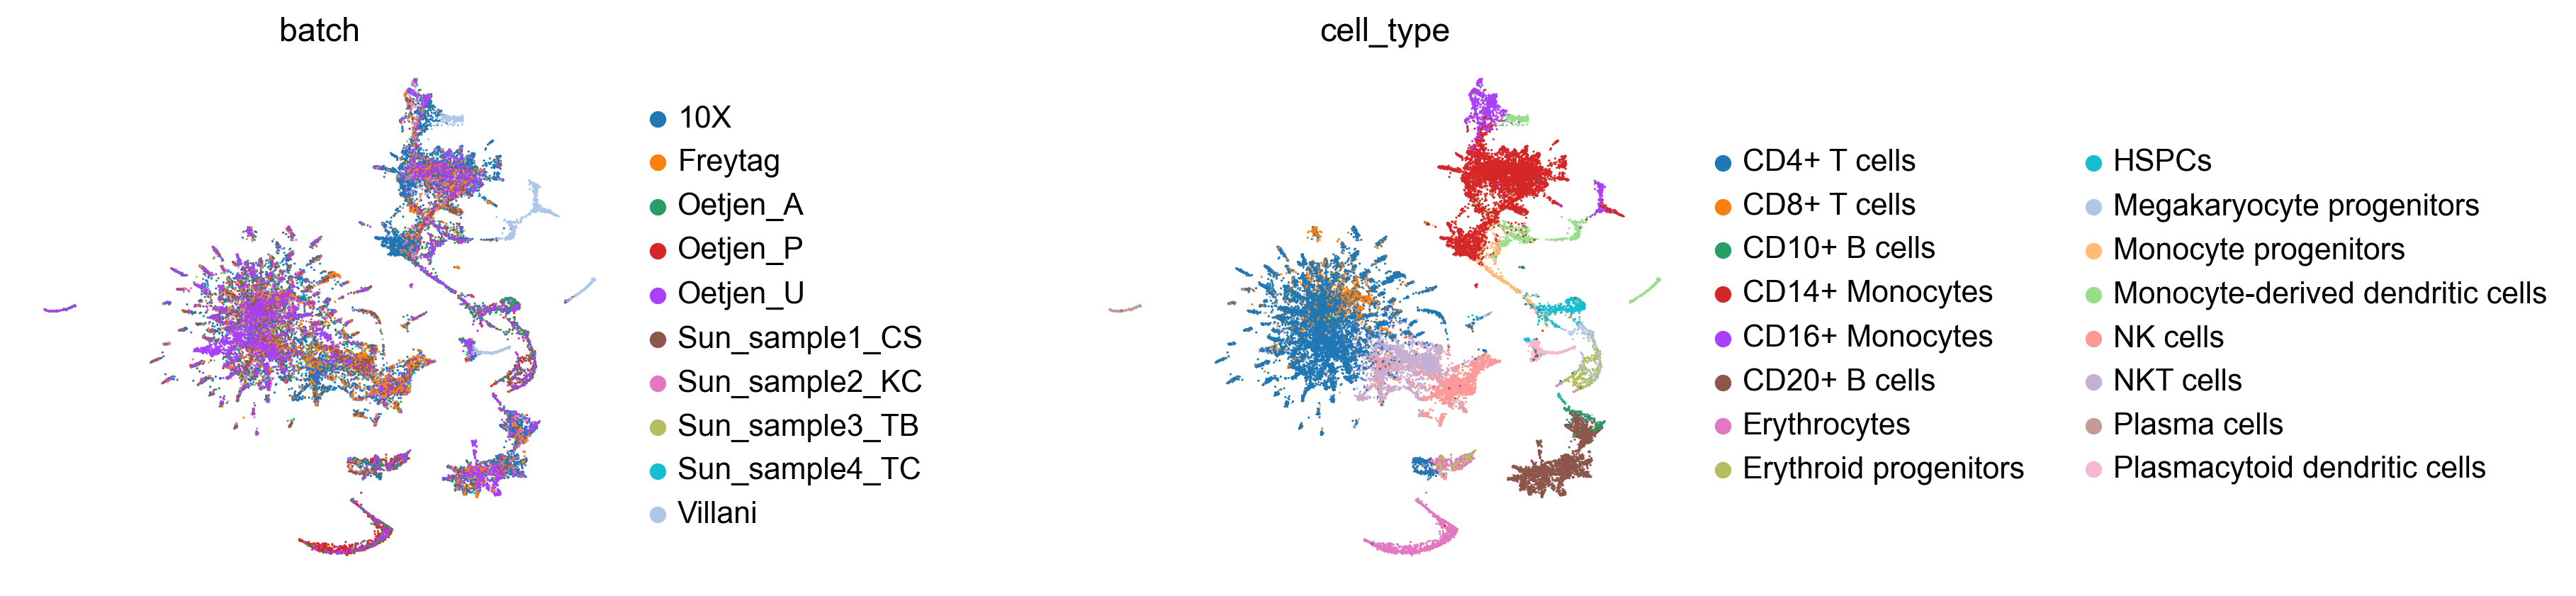

In [9]:
sc.pl.embedding(adata_int, basis='TopoMAP', color=['batch', 'cell_type'],
                frameon=False, wspace=0.6)

### Integration quality metrics

Visual inspection is important, but we also want **quantitative** measures of integration quality. `tp.sc.compute_all_integration_metrics` computes six complementary metrics:

| Metric | Measures | Good integration |
|---|---|---|
| **kNN purity** | Whether neighbours share the same cell type | High (close to 1) |
| **kNN mixing** | Whether neighbours come from different batches | High (close to 1) |
| **iLISI** | Local Inverse Simpson Index for batch mixing | High (up to n_batches) |
| **cLISI** | Local Inverse Simpson Index for cell-type purity | Low (close to 1) |
| **ARI** | Adjusted Rand Index (cluster vs cell-type agreement) | High (close to 1) |
| **NMI** | Normalised Mutual Information (cluster vs cell-type) | High (close to 1) |

We compare the integrated data against an uncorrected baseline (same features, no batch correction):

In [22]:
# Subset original data to the same features for fair comparison
features_w1 = list(adata_int.var_names)
adata_uncorr_w1 = adata_w1[:, features_w1].copy()

metrics_w1 = tp.sc.compute_all_integration_metrics(
    {
        'uncorrected': adata_uncorr_w1,
        'integrated':  adata_int,
    },
    batch_key='batch',
    cell_type_key='cell_type',
    cluster_key='topo_clusters',
    k=100,
    n_jobs=-1,
)

print("=== Workflow 1 — Integration metrics ===")
print(metrics_w1.to_string(float_format='{:.4f}'.format))

=== Workflow 1 — Integration metrics ===
            uncorrected  integrated
knn_purity       0.8202      0.8304
knn_mixing       0.4832      0.6959
ilisi            2.3840      4.6099
clisi            1.1514      1.1022
ari                 NaN      0.5139
nmi                 NaN      0.6430


The iLISI score (batch mixing) should increase substantially after integration, while cLISI (cell-type purity) should remain close to 1 — indicating that batch effects were removed without blurring biological distinctions.

---
## Workflow 2 — Reference atlas + sequential query mapping

In many practical scenarios, you want to build a **stable reference atlas** and then map new samples onto it — for instance, when new patient cohorts arrive over time, or when you want to annotate new experiments against a well-characterised reference. This workflow supports that use case:

1. **Integrate** a subset of batches to build a reference.
2. **Save** the reference to disk for re-use.
3. **Prepare** held-out query batches.
4. **Find the optimal mapping order** (most similar queries first).
5. **Map** all queries sequentially.
6. **Fit TopOGraph** on the final atlas and evaluate.

```
prepare_for_integration(ref)  →  run_cca_integration(ref)  →  save_cca_reference
prepare_for_mapping(queries)  →  find_mapping_order  →  map_to_cca_reference
fit_adata(atlas)  →  compute_all_integration_metrics
```

### Define reference and query batches

We use 6 batches as the reference and hold out 4 as queries. In practice, you would choose reference batches that are well-characterised and cover the expected biological diversity:

In [11]:
REF_BATCHES   = ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P',
                 'Sun_sample1_CS', 'Sun_sample2_KC']
QUERY_BATCHES = ['Oetjen_U', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']

adata_ref_raw = adata[adata.obs['batch'].isin(REF_BATCHES)].copy()
adata_queries_raw = [
    adata[adata.obs['batch'] == b].copy() for b in QUERY_BATCHES
]

print(f"Reference batches ({len(REF_BATCHES)}): {REF_BATCHES}")
print(f"Query batches     ({len(QUERY_BATCHES)}): {QUERY_BATCHES}")
print(f"\nReference cells: {adata_ref_raw.n_obs:,}")
for b, q in zip(QUERY_BATCHES, adata_queries_raw):
    print(f"  Query '{b}': {q.n_obs:,} cells")

Reference batches (6): ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P', 'Sun_sample1_CS', 'Sun_sample2_KC']
Query batches     (4): ['Oetjen_U', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']

Reference cells: 23,931
  Query 'Oetjen_U': 3,730 cells
  Query 'Sun_sample3_TB': 2,403 cells
  Query 'Sun_sample4_TC': 2,420 cells
  Query 'Villani': 1,022 cells


### Prepare and integrate the reference

The reference is prepared and integrated exactly as in Workflow 1:

In [12]:
tp.sc.prepare_for_integration(
    adata_ref_raw,
    batch_key='batch',
    input_type='lognorm',
    select_hvgs=True,
    n_hvgs=2000,
)

print(f"Selected {len(adata_ref_raw.uns['integration_features'])} integration features for the reference.")

Selected 2000 integration features for the reference.


In [13]:
adata_ref = tp.sc.run_cca_integration(
    adata_ref_raw,
    batch_key='batch',
    n_components=30,
    scale_output=True,
    n_jobs=-1,
)

print(f"Reference integrated: {adata_ref.shape[0]:,} cells, {adata_ref.shape[1]} features")

Reference integrated: 23,931 cells, 2000 features


### Save and load the reference

A key advantage of this workflow is **persistence** — you can save the integrated reference to disk and re-use it later without re-running the integration. The CCA loadings and integration metadata are preserved:

In [14]:
REFERENCE_PATH = '/tmp/immune_cca_reference.h5ad'

tp.sc.save_cca_reference(adata_ref, REFERENCE_PATH)
print(f"Reference saved to {REFERENCE_PATH}")

# Demonstrate round-trip: load it back
adata_ref_loaded = tp.sc.load_cca_reference(REFERENCE_PATH)
print(f"Loaded reference: {adata_ref_loaded.shape[0]:,} cells, {adata_ref_loaded.shape[1]} features")

Reference saved to /tmp/immune_cca_reference.h5ad
Loaded reference: 23,931 cells, 2000 features


### Prepare query datasets

`tp.sc.prepare_for_mapping` ensures each query dataset is normalised consistently with the reference and checks **feature overlap** — how many of the reference's integration features are present in each query:

In [15]:
tp.sc.prepare_for_mapping(
    adata_queries_raw,
    adata_ref,
    batch_key='batch',
    input_type='lognorm',
)

for b, q in zip(QUERY_BATCHES, adata_queries_raw):
    shared = sum(g in set(adata_ref.var_names) for g in q.var_names)
    print(f"  '{b}': {shared}/{adata_ref.n_vars} reference features covered")

  'Oetjen_U': 2000/2000 reference features covered
  'Sun_sample3_TB': 2000/2000 reference features covered
  'Sun_sample4_TC': 2000/2000 reference features covered
  'Villani': 2000/2000 reference features covered


### Find the optimal mapping order

When mapping multiple query batches, it helps to start with the ones most similar to the reference — they contribute the most reliable anchors and produce a more stable atlas. `tp.sc.find_mapping_order` ranks queries by their CCA similarity to the current reference:

In [16]:
mapping_order = tp.sc.find_mapping_order(
    adata_ref,
    adata_queries_raw,
    n_components=10,
    k=5,
    n_jobs=-1,
)

print("Optimal mapping order (most → least similar to reference):")
for rank, idx in enumerate(mapping_order):
    print(f"  {rank+1}. {QUERY_BATCHES[idx]}")

Optimal mapping order (most → least similar to reference):
  1. Oetjen_U
  2. Sun_sample3_TB
  3. Sun_sample4_TC
  4. Villani


### Map queries to the reference

`tp.sc.map_to_cca_reference` projects each query batch onto the reference, correcting batch effects using the frozen CCA space. Setting `return_intermediates=True` collects the atlas state after each mapping step — useful for tracking how integration metrics evolve:

In [17]:
adata_atlas, steps = tp.sc.map_to_cca_reference(
    adata_queries_raw,
    adata_ref,
    mode='query_only',
    mapping_order=mapping_order,
    sequential_topometry=False,
    return_intermediates=True,
    n_jobs=-1,
)

print(f"Final atlas: {adata_atlas.shape[0]:,} cells, {adata_atlas.shape[1]} features")
print(f"\nCells per batch:")
print(adata_atlas.obs['batch'].value_counts().to_string())

Final atlas: 33,506 cells, 2000 features

Cells per batch:
batch
10X               10727
Oetjen_U           3730
Freytag            3347
Oetjen_P           3265
Oetjen_A           2586
Sun_sample4_TC     2420
Sun_sample3_TB     2403
Sun_sample2_KC     2281
Sun_sample1_CS     1725
Villani            1022


### Fit TopOGraph on the final atlas

With all batches mapped, we fit the full TopoMetry pipeline on the combined atlas:

In [18]:
tg_atlas = tp.sc.fit_adata(
    adata_atlas,
    projections=('MAP'),
    do_leiden=True,
    leiden_resolutions=(0.3,),
    n_jobs=-1,
)

print("Available embeddings:", [k for k in adata_atlas.obsm.keys()])

Available embeddings: ['X_ms_spectral_scaffold', 'X_spectral_scaffold', 'X_msTopoMAP', 'X_TopoMAP']


### Visualise the atlas

Let's inspect the final atlas. We add an `origin` column to distinguish reference from query cells, then colour by batch, origin, and cell type:

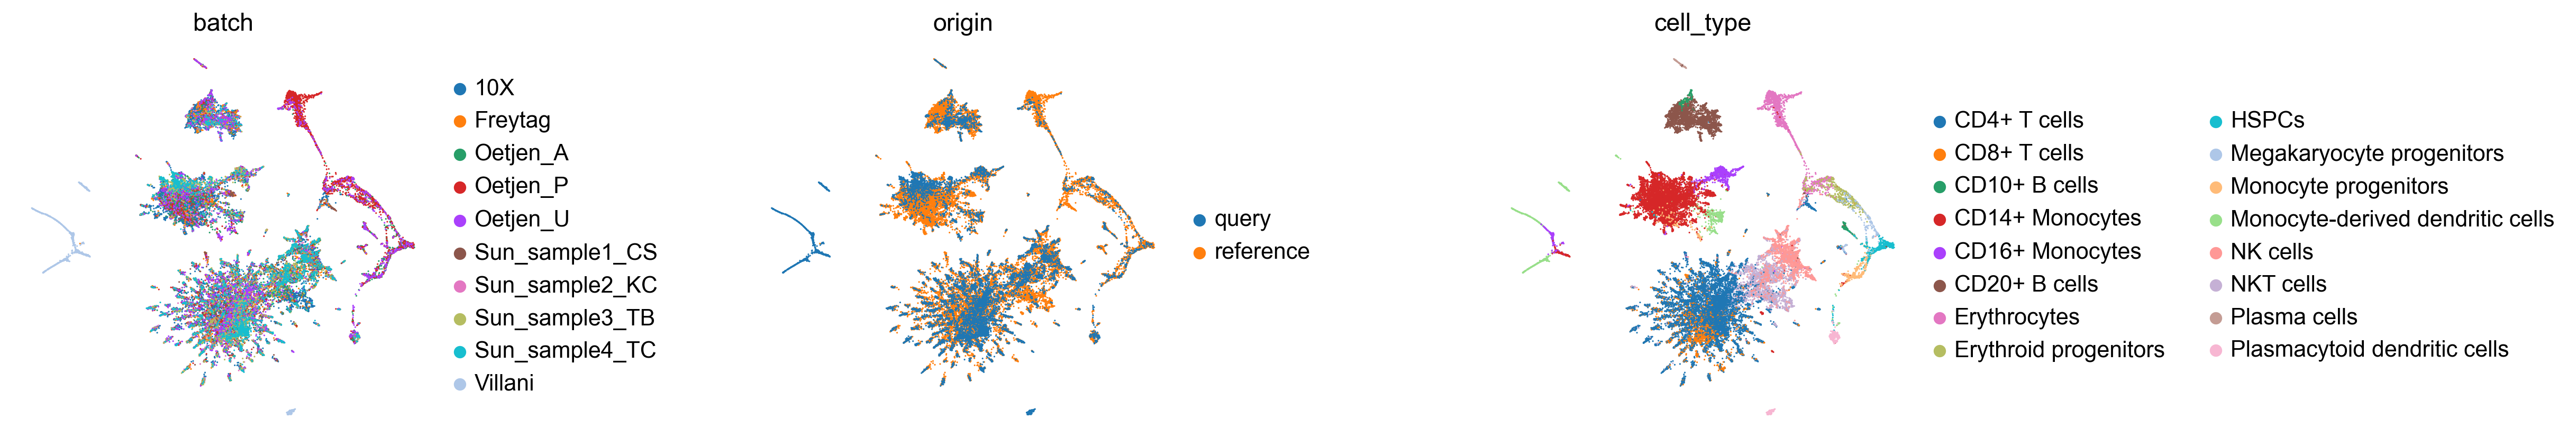

In [19]:
adata_atlas.obs['origin'] = np.where(
    adata_atlas.obs['batch'].isin(REF_BATCHES), 'reference', 'query'
)

sc.pl.embedding(adata_atlas, basis='TopoMAP',
                color=['batch', 'origin', 'cell_type'],
                frameon=False, wspace=0.6)

Reference and query cells should overlap for the same cell types, with batches well-mixed within each population.

### Integration quality metrics

We build a comprehensive comparison table: uncorrected data, the reference alone, each intermediate mapping step, and the final atlas. This lets us track how batch mixing and cell-type preservation evolve as queries are added:

In [23]:
# Uncorrected baseline: original lognorm data, same features as the reference
features_ref = list(adata_ref.var_names)
adata_uncorr_w2 = adata[:, [g for g in features_ref if g in adata.var_names]].copy()

adata_dict_w2 = {
    'uncorrected': adata_uncorr_w2,
    'reference':   adata_ref,
}

# Add intermediate steps with descriptive labels
for label in sorted(steps.keys()):
    step_idx = int(label.split('_')[1])
    query_name = QUERY_BATCHES[mapping_order[step_idx]]
    adata_dict_w2[f'{label} (+{query_name})'] = steps[label]

adata_dict_w2['final_atlas'] = adata_atlas

metrics_w2 = tp.sc.compute_all_integration_metrics(
    adata_dict_w2,
    batch_key='batch',
    cell_type_key='cell_type',
    cluster_key='topo_clusters',
    k=100,
    n_jobs=-1,
)

print("=== Workflow 2 — Integration metrics ===")
print(metrics_w2.to_string(float_format='{:.4f}'.format))

=== Workflow 2 — Integration metrics ===
            uncorrected  reference  step_0 (+Oetjen_U)  step_1 (+Sun_sample3_TB)  step_2 (+Sun_sample4_TC)  step_3 (+Villani)  final_atlas
knn_purity       0.8191     0.6845              0.6856                    0.6896                    0.6921             0.7201       0.8390
knn_mixing       0.4847     0.8149              0.8413                    0.8542                    0.8653             0.8649       0.6737
ilisi            2.3673     2.7598              2.7811                    2.9519                    3.1464             3.2433       4.0883
clisi            1.1513     1.2424              1.2235                    1.2418                    1.2384             1.1989       1.0991
ari                 NaN        NaN                 NaN                       NaN                       NaN                NaN       0.5467
nmi                 NaN        NaN                 NaN                       NaN                       NaN                NaN

As queries are added, iLISI (batch mixing) should increase progressively while cLISI (cell-type purity) remains stable — confirming that the sequential mapping removes batch effects without distorting biology.

---
## Summary

In this tutorial we covered two complementary integration workflows:

| | Workflow 1 (full integration) | Workflow 2 (reference mapping) |
|---|---|---|
| **When to use** | All data available upfront | New batches arrive over time |
| **API** | `prepare_for_integration` → `run_cca_integration` | Same for reference, then `map_to_cca_reference` for queries |
| **Reference persistence** | Not applicable | `save_cca_reference` / `load_cca_reference` |
| **Downstream** | `fit_adata` → layouts, clustering, metrics | Same |

Both workflows use the same underlying CCA-anchor correction. The sequential mapping approach is best suited for incrementally extending a stable reference atlas as new data becomes available.

**What's next?**

- Explore the [Step-by-Step tutorial](T2_step_by_step.ipynb) to learn how to tune individual TopoMetry components.
- Use `tp.sc.impute_adata()` on the integrated data for denoised gene expression.
- Apply `tp.sc.evaluate_representations()` and `tp.sc.plot_riemann_diagnostics()` to assess the quality of integrated embeddings.